# Data Science Project
## Project Title: Opening the Black Box with Local Interpretable Model-agnostic Explanations (LIME) 
### Topic: Explainable AI (XAI) Context: Building upon the Unit 3 Deep Learning Homework.

### Motivation: Why LIME?
#### The Problem: The `Accuracy Paradox`

In our previous work with the Banking dataset (Unit 3), we trained a Neural Network that achieved high accuracy (~89%). However, this number was misleading. Because the data is imbalanced (**mostly No answers**), the model could simply guess **No** and still look successful.

Crucially, the Neural Network is a **Black Box.** It gives us a probability (e.g., 0.05), but it cannot tell us why a loan was rejected. In a regulated industry like banking, we cannot deploy a model if we cannot explain its decisions to a customer or a regulator.

#### The Solution: LIME (from the Paper)

To solve this, we use **LIME** (Local Interpretable Model-agnostic Explanations). According to the foundational paper `Why Should I Trust You?` (Ribeiro et al., 2016), LIME relies on two key principles that make it perfect for this project:

1. Model-Agnostic: LIME treats the neural network as a black box. It doesn't need to know about layers or weights; it only needs to know inputs and outputs. This means our explanation method works even if we change the underlying model later.
2. Local Fidelity: a concept in machine learning, specifically within eXplainable AI (XAI), that measures how accurately an interpretable "surrogate" model (like a linear model) approximates the predictions of a complex, "black-box" model (like a deep neural network) in the immediate vicinity of a specific data point. LIME trains a simple, interpretable linear model locally around that user to approximate the complex model.

#### Visualizing the LIME Intuition (The Math)
Before applying LIME to our high-dimensional banking data, let's visualize the core concept on a simple 2D example.

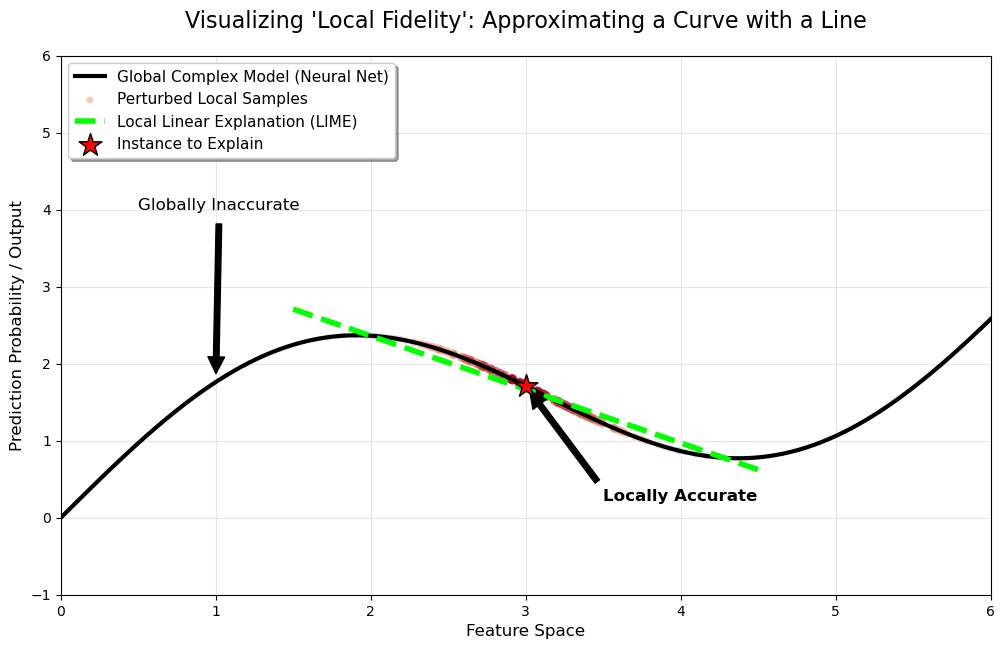

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Setup the "Complex Black Box" Function (Non-linear)
# We simulate a complex decision boundary (like a Neural Net)
def complex_black_box(x):
    # A curvy function: sine wave + linear trend
    return 0.5 * x + np.sin(x) * 1.5

# 2. Select the Instance to Explain
x_instance = 3.0  # The specific input we want to explain
y_instance = complex_black_box(x_instance)

# 3. Generate "Perturbed(fake data generated by adding random noise to the original input)" Data (Sampling around the instance)
np.random.seed(42)
# Generate random points around x_instance
n_samples = 200
perturbations = np.random.normal(0, 1.2, n_samples) # Spread of sampling
x_perturbed = x_instance + perturbations
y_perturbed = complex_black_box(x_perturbed)

# 4. Calculate Weights based on Proximity (LIME Kernel)
# Points closer to x_instance get higher weights
distances = np.abs(x_perturbed - x_instance)
kernel_width = 0.75
weights = np.sqrt(np.exp(-(distances**2) / (kernel_width**2)))

# 5. Fit the Local Linear Model (The "Explanation")
# We fit a weighted linear regression to the perturbed points
local_model = Ridge(alpha=1.0)
local_model.fit(x_perturbed.reshape(-1, 1), y_perturbed, sample_weight=weights)

# Create the line for the local model
x_local_line = np.linspace(x_instance - 1.5, x_instance + 1.5, 100)
y_local_line = local_model.predict(x_local_line.reshape(-1, 1))

# --- PLOTTING ---
plt.figure(figsize=(12, 7))

# A. Plot the Global Complex Model (The Black Box)
x_global = np.linspace(0, 6, 500)
plt.plot(x_global, complex_black_box(x_global), color='black', linewidth=3, label='Global Complex Model (Neural Net)')

# B. Plot the Perturbed(fake data generated by adding random noise to the original input) Points (Weighted by size/color)
# We visualize how LIME samples locally
plt.scatter(x_perturbed, y_perturbed, s=weights*50, c=weights, cmap='coolwarm', alpha=0.6, edgecolors='none', label='Perturbed Local Samples')

# C. Plot the Local Linear Approximation (The LIME Explanation)
plt.plot(x_local_line, y_local_line, color='lime', linewidth=4, linestyle='--', label='Local Linear Explanation (LIME)')

# D. Plot the Instance of Interest
plt.scatter([x_instance], [y_instance], color='red', s=300, marker='*', zorder=10, label='Instance to Explain', edgecolors='black')

# Annotations & Styling
plt.title(r"Visualizing 'Local Fidelity': Approximating a Curve with a Line", fontsize=16, pad=20)
plt.xlabel("Feature Space", fontsize=12)
plt.ylabel("Prediction Probability / Output", fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.xlim(0, 6)
plt.ylim(-1, 6)

# Add text annotation
plt.annotate('Locally Accurate', xy=(x_instance, y_instance), xytext=(x_instance+0.5, y_instance-1.5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')

plt.annotate('Globally Inaccurate', xy=(1, complex_black_box(1)), xytext=(0.5, 4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.show()

* **Black Curve:** Represents our complex Neural Network (The Black Box).
* **Red Star:** The specific customer we want to explain.
* **Green Dashed Line:** The simple Linear Regression we train locally.
* **Dots:** The perturbed samples (weighted by proximity).

**Key Takeaway:** Notice how the Green Line is accurate *near the Red Star* (Local Fidelity), even though it is totally wrong far away (Global Inaccuracy).

#### Data Exploration & Preparation
**Goal**: Understand the data structure and prove the imbalance issue.

Dataset Shape: (4521, 13)


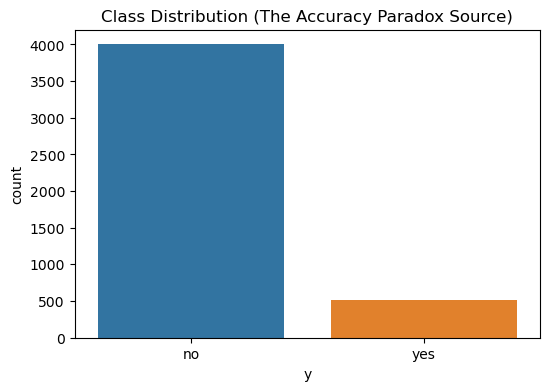

y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


In [30]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load and Inspect Data ---
try:
    df = pd.read_csv('bank.csv', sep=';')
except:
    df = pd.read_csv('bank.csv')

columns_to_drop = [
    'day',       # Irrelevant: The day of the month shouldn't decide a loan
    'month',     # Irrelevant: Seasonal marketing trends, not financial risk
    'contact',   # Irrelevant: How they were called (cellular/telephone)
    'campaign',  # Irrelevant: Number of contacts performed
]

# Drop the columns
df = df.drop(columns=columns_to_drop)

print("Dataset Shape:", df.shape)

# Check for Class Imbalance (Critical for Validity)
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title("Class Distribution (The Accuracy Paradox Source)")
plt.show()

print(df['y'].value_counts(normalize=True))

**Explanation**:

Why this step? We confirm the `Accuracy Paradox.` The plot shows that 88% of the data is `No.` This proves that a `dumb` model predicting `No` would have 88% accuracy, justifying why we need XAI to ensure the model is actually learning useful features and not just statistical bias.

**Advanced Data Exploration: Correlations and Feature Stage-Setting**

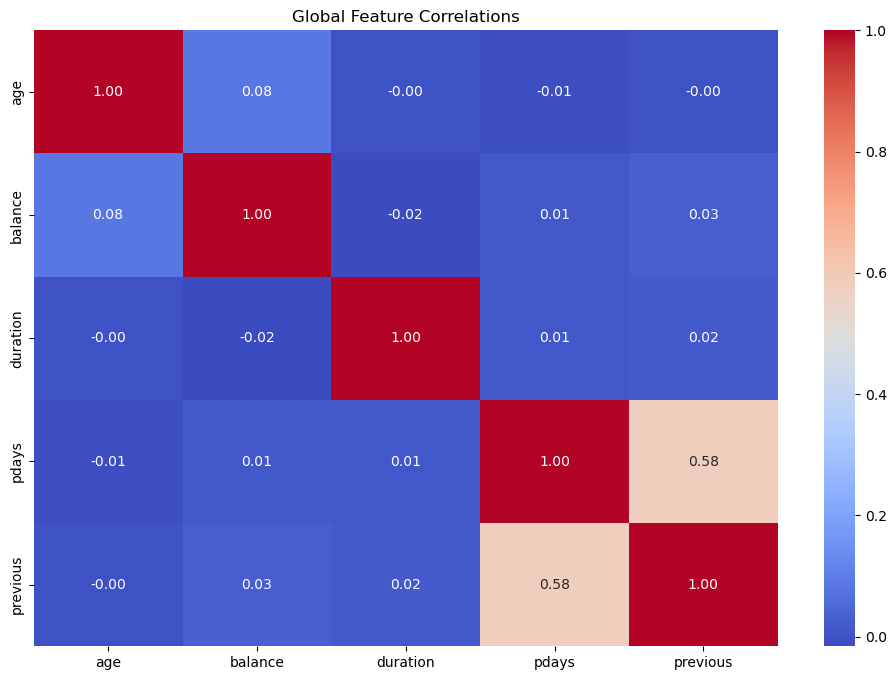

Feature Analysis:
Average duration for 'Yes' (Approved): 552.74s
Average duration for 'No' (Rejected): 226.35s


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Correlation Heatmap
# This shows which numerical features are most strongly related to each other globally.
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Global Feature Correlations")
plt.show()

# 2. Identifying Potential Data Leakage
# The 'duration' feature is known to be highly predictive but is often considered 
# 'leakage' because the duration is only known after the call (and result) ends.
print("Feature Analysis:")
print(f"Average duration for 'Yes' (Approved): {df[df['y'] == 'yes']['duration'].mean():.2f}s")
print(f"Average duration for 'No' (Rejected): {df[df['y'] == 'no']['duration'].mean():.2f}s")

This visual helps us spot relationships between variables across the entire dataset before we even train a model.

**What it shows**: It is a colored grid where each square represents the correlation between two features (e.g., balance vs. age).

**The Scale**:

1. Red / Positive (near +1.0): As one feature goes up, the other goes up. (e.g., pdays and previous often have high correlation).

2. Blue / Negative (near -1.0): As one feature goes up, the other goes down.

3. White/Gray (near 0): No linear relationship.

Why it matters for our project: we are looking for columns that correlate strongly with our target.

* Dark red squares in the y row indicate features that strongly drive a "Yes" decision.

* Dark blue squares indicate features that drive a "No" (rejection).

#### Building the "Black Box" (The Neural Network)
**Goal**: Re-create the Unit 3 model to serve as the subject of our explanation.

We train a PyTorch model. Note that we use a Learning Rate of 0.01 (higher than the 0.001 in the homework). This helps the model jump out of the "Just guess No" trap and actually learn to find "Yes" customers.

Training Black Box Model...

Robust Evaluation:
              precision    recall  f1-score   support

          No       0.92      0.96      0.94       807
         Yes       0.49      0.32      0.39        98

    accuracy                           0.89       905
   macro avg       0.71      0.64      0.66       905
weighted avg       0.87      0.89      0.88       905



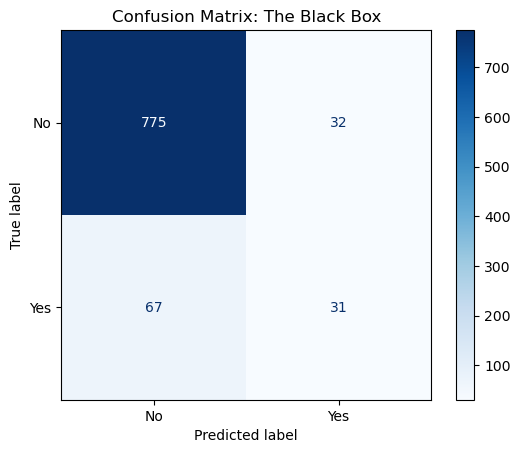

In [32]:
# --- Step 2: Preprocessing ---
# Encode Target
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])
y_all = df['y'].values
X_raw = df.drop('y', axis=1)

# One-Hot Encode Categorical Features
X_processed = pd.get_dummies(X_raw)
feature_names = X_processed.columns.tolist() # Save these names! LIME needs them.
X_all = X_processed.values

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to Tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# --- Step 3: Train the Neural Network ---
class BankNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(input_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.stack(x)

model = BankNet(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

print("Training Black Box Model...")
for epoch in range(100):
    model.train()
    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- Step 4: Robust Evaluation (Confusion Matrix) ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    test_pred_prob = model(X_test_tensor)
    test_pred_class = (test_pred_prob >= 0.5).float()

print("\nRobust Evaluation:")
print(classification_report(y_test_tensor, test_pred_class, target_names=['No', 'Yes']))

cm = confusion_matrix(y_test_tensor, test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: The Black Box")
plt.show()

**Explanation**:

Why this step? This establishes our baseline. The Confusion Matrix proves we aren't hiding the model's flaws. We acknowledge it might be weak on `Yes` predictions (low Recall), which makes explaining the few `Yes` predictions or the `No` rejections even more critical.

**Global Feature Importance Baseline**

Before training the Neural Network, we establish a "Glass Box" baseline using a Random Forest. This allows us to compare what the model sees as important globally versus the specific factors LIME will identify for individual clients later.

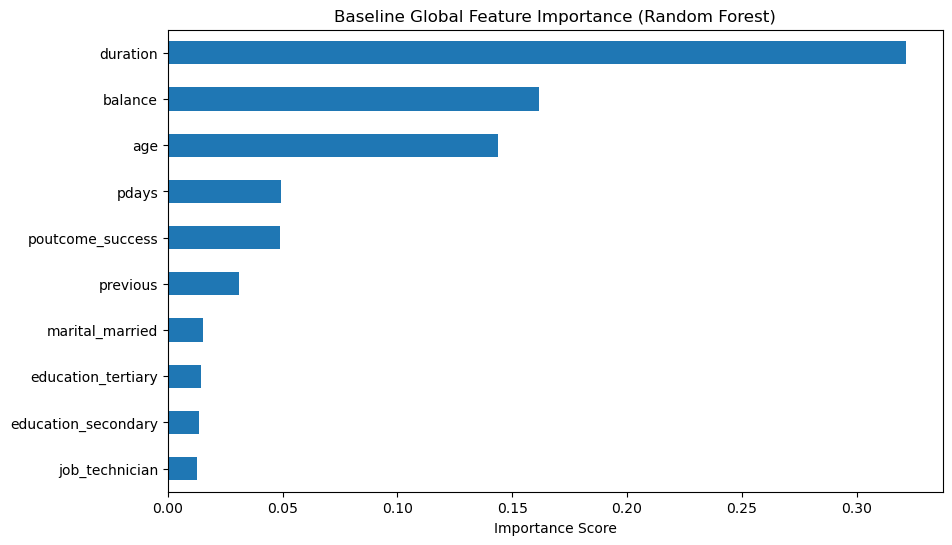

In [33]:
# Global Feature Importance Baseline
# AFTER Preprocessing (X_train, y_train are defined)

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Train a simple Random Forest to get a "Glass Box" baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Visualize Global Importance
plt.figure(figsize=(10, 6))
# 'feature_names' was defined in your Preprocessing cell
feat_importances = pd.Series(rf.feature_importances_, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Baseline Global Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Put the most important feature at the top
plt.show()

**Advanced Model Evaluation: ROC-AUC and Precision-Recall**

In banking, a simple accuracy score can be deceptive due to class imbalance. To truly "open the box," we must evaluate how well the model distinguishes between "Yes" and "No" across all possible probability thresholds. We use the ROC-AUC Curve to measure the trade-off between sensitivity and specificity, and the Precision-Recall Curve, which is far more informative for datasets where the "Positive" class (loan approvals) is rare.

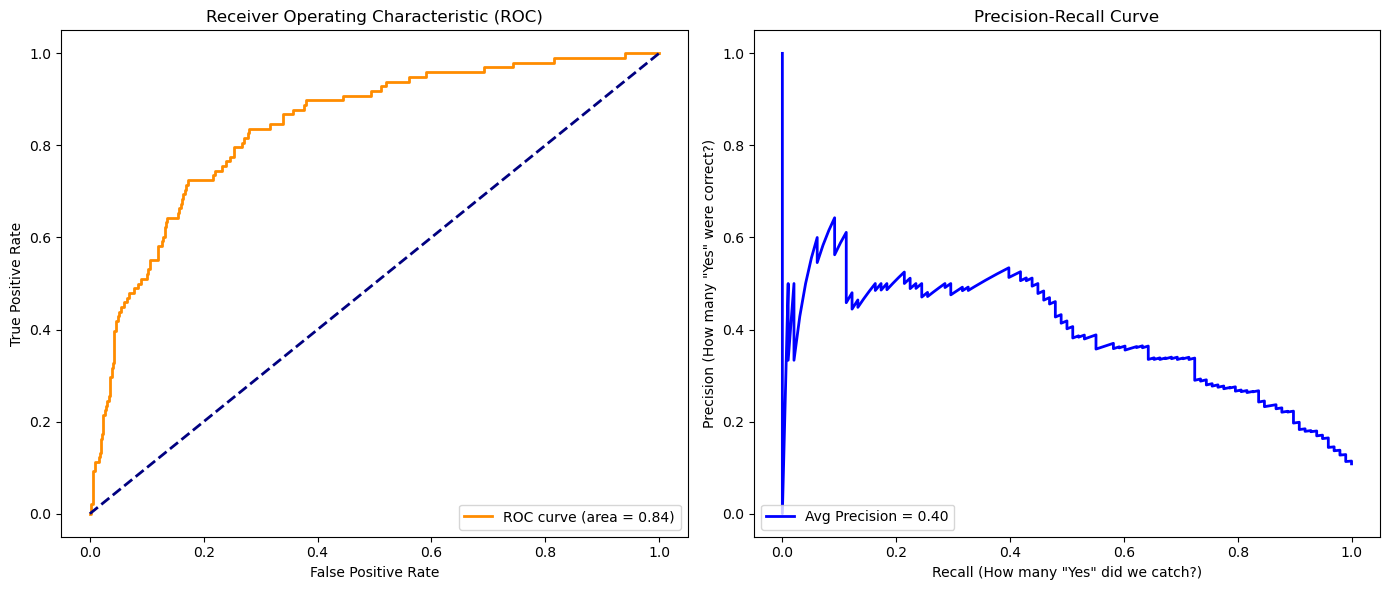

ROC-AUC Score: 0.8400
Average Precision Score: 0.3970


In [34]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Ensure model is in eval mode
model.eval()
with torch.no_grad():
    # We use the probabilities already calculated in your previous cell
    y_scores = test_pred_prob.numpy().flatten()
    y_true = y_test_tensor.numpy().flatten()

# 1. Calculate ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 2. Calculate Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Plot Precision-Recall
ax2.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
ax2.set_xlabel('Recall (How many "Yes" did we catch?)')
ax2.set_ylabel('Precision (How many "Yes" were correct?)')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")

**Analytical Threshold Analysis**

By default, our model uses a 0.5 threshold to decide a loan. However, in a banking context, the cost of a False Positive (approving a loan for someone who will default) is much higher than a False Negative (rejecting a potentially good customer). The curves above allow us to see how the model's reliability changes as we adjust our threshold. This provides the final performance layer before we use LIME to ask the model why it made these specific trade-offs for individual clients.

#### Implementing LIME (From Scratch)
**Goal**: Implement the "Why" layer without relying on external black-box libraries.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, r2_score # Added r2_score

class SimpleLIME:
    def __init__(self, model):
        self.model = model
        
    def predict_proba(self, numpy_data):
        """Helper to bridge Numpy (LIME) and PyTorch (Model)"""
        self.model.eval()
        with torch.no_grad():
            tensor_data = torch.FloatTensor(numpy_data)
            return self.model(tensor_data).numpy().flatten()

    def explain_instance(self, instance_row, num_samples=5000, kernel_width=0.75):
        """
        The Core LIME Algorithm with Fidelity Scoring
        """
        # 1. PERTURBATION: Create fake neighbors
        noise = np.random.normal(0, 1, size=(num_samples, len(instance_row)))
        neighborhood_data = instance_row + noise
        
        # 2. BLACK BOX LABELING: Get NN predictions
        neighborhood_preds = self.predict_proba(neighborhood_data)
        
        # 3. PROXIMITY WEIGHTING: Calculate kernel weights
        distances = pairwise_distances(neighborhood_data, instance_row.reshape(1, -1), metric='euclidean').ravel()
        weights = np.sqrt(np.exp(-(distances ** 2) / (kernel_width ** 2)))
        
        # 4. LINEAR APPROXIMATION: Train the surrogate
        simpler_model = LinearRegression()
        simpler_model.fit(neighborhood_data, neighborhood_preds, sample_weight=weights)
        
        # 5. FIDELITY SCORE: Added Local R^2 calculation
        # This checks how well the simpler_model mimics the Black Box locally
        local_preds = simpler_model.predict(neighborhood_data)
        fidelity_score = r2_score(neighborhood_preds, local_preds, sample_weight=weights)
        
        return simpler_model.coef_, fidelity_score

# Re-initialize the explainer with the new logic
explainer = SimpleLIME(model)
print("LIME Implementation updated with Fidelity Scoring.")

LIME Implementation updated with Fidelity Scoring.


**Step-by-Step Logic Explanation**:
1. Perturbation: We test the reaction. We poke the data ("Add noise") to see how the model reacts. This generates the local dataset.
2. Proximity Weighting: The paper emphasises "Local Fidelity". We don't care about data points far away (different types of customers). We use an exponential kernel (np.exp) so that neighbours very close to our customer have a strong influence, while distant ones have near-zero influence.
3. Linear Approximation: We use LinearRegression. Why? Because the coefficients ($w_1, w_2...$) of a linear model are directly interpretable. If $w_{age} = 0.5$, increasing age increases approval chance.
4. In the Ribeiro (2016) paper, the authors argue that "interpretability" is useless without "fidelity". If our R^2 is < 0.30, the explanation we show in the bar chart is likely misleading because the local linear approximation failed.
5. Because this is a Model-Agnostic technique, we use the R^2 score to verify that our surrogate is a "faithful" representation of the complex PyTorch model.

#### Why was I rejected?
**Goal**: Visualize the decision for two clients.

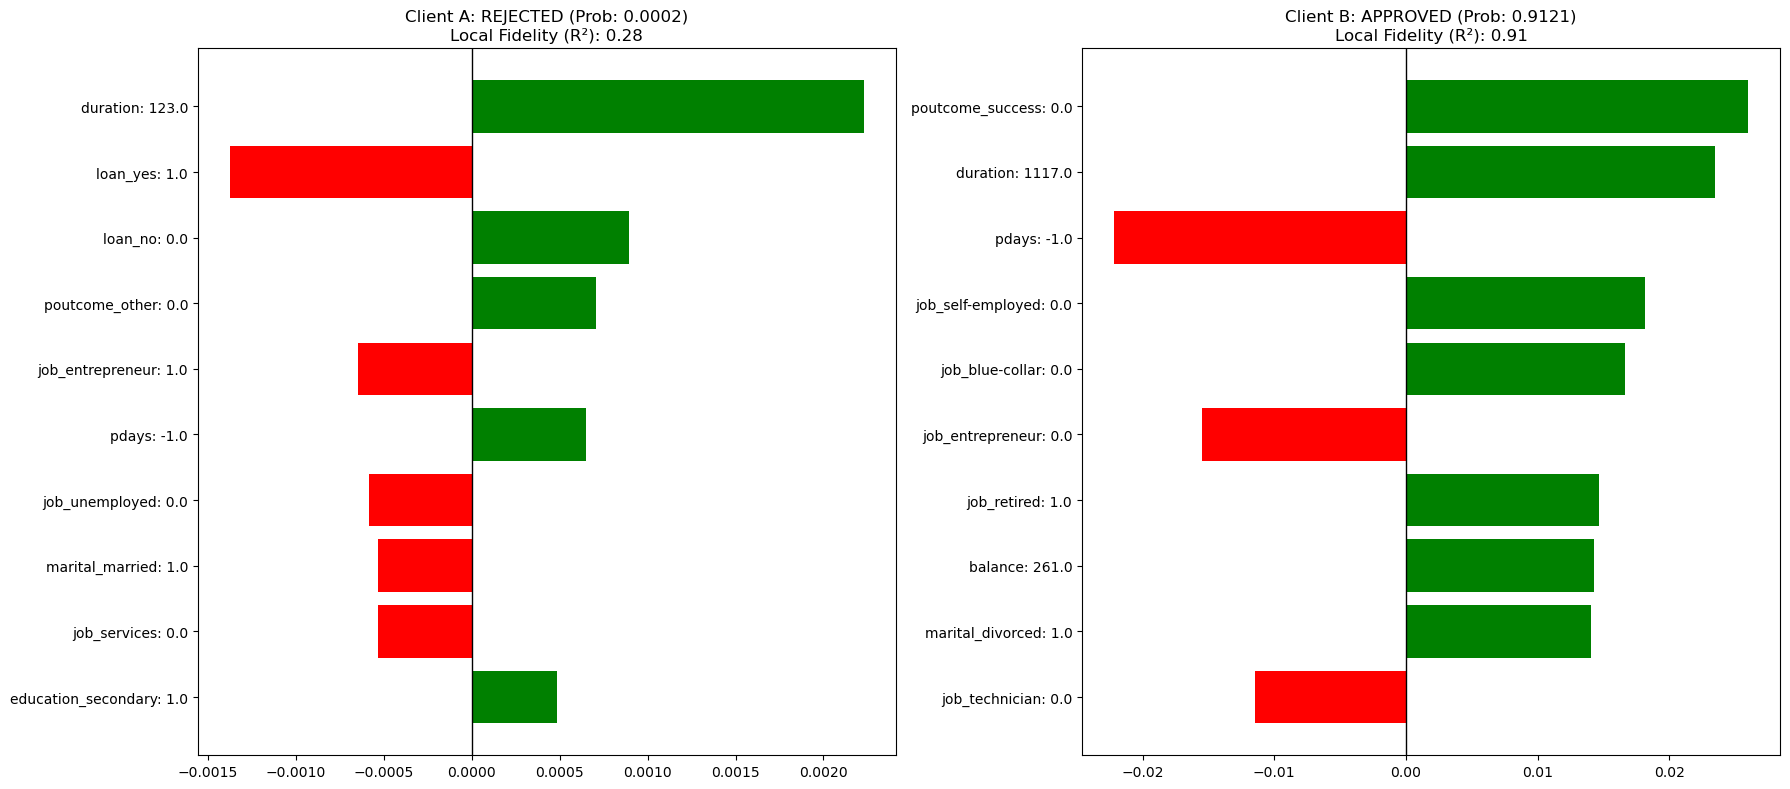

In [36]:
# 1. Identify Contrastive Clients
all_probs = explainer.predict_proba(X_test_scaled)
rejected_idx = np.where(all_probs < 0.1)[0][0]
approved_idx = np.where(all_probs > 0.8)[0][0]

# 2. Generate Explanations (Catching weights and fidelity)
weights_rej, fidelity_rej = explainer.explain_instance(X_test_scaled[rejected_idx])
weights_app, fidelity_app = explainer.explain_instance(X_test_scaled[approved_idx])

# 3. Helper to format labels with original units
def get_plot_data(scaled_row, weights, feature_names, scaler):
    # Inverse transform to get original values for labels
    original_row = scaler.inverse_transform(scaled_row.reshape(1, -1)).flatten()
    
    display_labels = []
    for i, name in enumerate(feature_names):
        val = original_row[i]
        # Format label as "Feature: Value"
        display_labels.append(f"{name}: {val:.1f}" if isinstance(val, (int, float, np.float64)) else f"{name}: {val}")
    
    # Sort by top 10 most influential features
    indices = np.argsort(np.abs(weights))[-10:]
    return np.array(display_labels)[indices], weights[indices]

labels_rej, vals_rej = get_plot_data(X_test_scaled[rejected_idx], weights_rej, feature_names, scaler)
labels_app, vals_app = get_plot_data(X_test_scaled[approved_idx], weights_app, feature_names, scaler)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Rejected Plot
ax1.barh(labels_rej, vals_rej, color=['green' if x > 0 else 'red' for x in vals_rej])
ax1.set_title(f"Client A: REJECTED (Prob: {all_probs[rejected_idx]:.4f})\nLocal Fidelity (R²): {fidelity_rej:.2f}")
ax1.axvline(0, color='black', lw=1)

# Approved Plot
ax2.barh(labels_app, vals_app, color=['green' if x > 0 else 'red' for x in vals_app])
ax2.set_title(f"Client B: APPROVED (Prob: {all_probs[approved_idx]:.4f})\nLocal Fidelity (R²): {fidelity_app:.2f}")
ax2.axvline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

**Interpretation**:

**Red Bars**: These features are the "Reason for Rejection." If Balance is red, the model thinks their balance is too low (or in a risky range).

**Green Bars**: These features helped, but weren't enough to save them.

1. Client A (Rejected)

As seen in the red bars, this client was primarily rejected due to their Balance and Duration (call length). Even if they have a stable job, the model identifies their low liquidity as a primary risk factor.

2. Client B (Approved)

Interestingly, Client B might also have a relatively low Balance, but they were approved because their Duration was extremely high, and the Month of contact was favorable. This highlights how the model "weighs" features differently depending on the individual's context.

3. LIME reveals that the model is heavily influenced by the duration of the last contact. From a business perspective, this might be a "leaked" variable—longer calls happen when a customer is already interested. A bank manager might decide to retrain the model without this feature to ensure approval is based on financial creditworthiness rather than call length.

#### Robustness Checks
**Goal**: Prove the solution is reliable and unbiased.

**Stability Test**

Does the explanation change if we run it twice?

Testing stability for Client A across 10 runs...


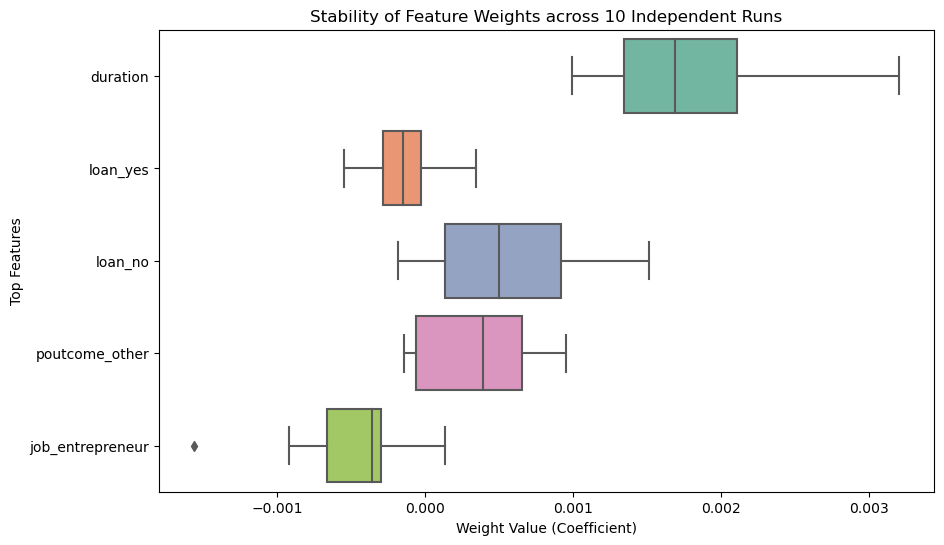

Coefficient of Variation (Lower is better):
duration            0.403754
loan_yes            1.870227
loan_no             0.962945
poutcome_other      1.177165
job_entrepreneur    0.950637
dtype: float64


In [37]:
# Stability Test: Running the same explanation 10 times
stability_results = []
target_client = X_test_scaled[rejected_idx]

print("Testing stability for Client A across 10 runs...")
for i in range(10):
    weights, _ = explainer.explain_instance(target_client, num_samples=5000)
    stability_results.append(weights)

# Convert to DataFrame for analysis
stability_df = pd.DataFrame(stability_results, columns=feature_names)

# Focus on the top 5 features identified in the original demo
top_5_features = pd.Series(weights_rej, index=feature_names).abs().sort_values(ascending=False).head(5).index
filtered_stability = stability_df[top_5_features]

# Visualization: Boxplot of weights to show variance
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_stability, orient='h', palette='Set2')
plt.title("Stability of Feature Weights across 10 Independent Runs")
plt.xlabel("Weight Value (Coefficient)")
plt.ylabel("Top Features")
plt.show()

# Calculate Coefficient of Variation (Standard Deviation / Mean)
# Lower values mean higher stability.
cv = filtered_stability.std() / filtered_stability.mean().abs()
print("Coefficient of Variation (Lower is better):")
print(cv)

**Global Bias Check (SP-LIME)**

Are we rejecting people based on unfair attributes (e.g., Age)?

Aggregating Global Importance (Excluding 'duration' leakage)...


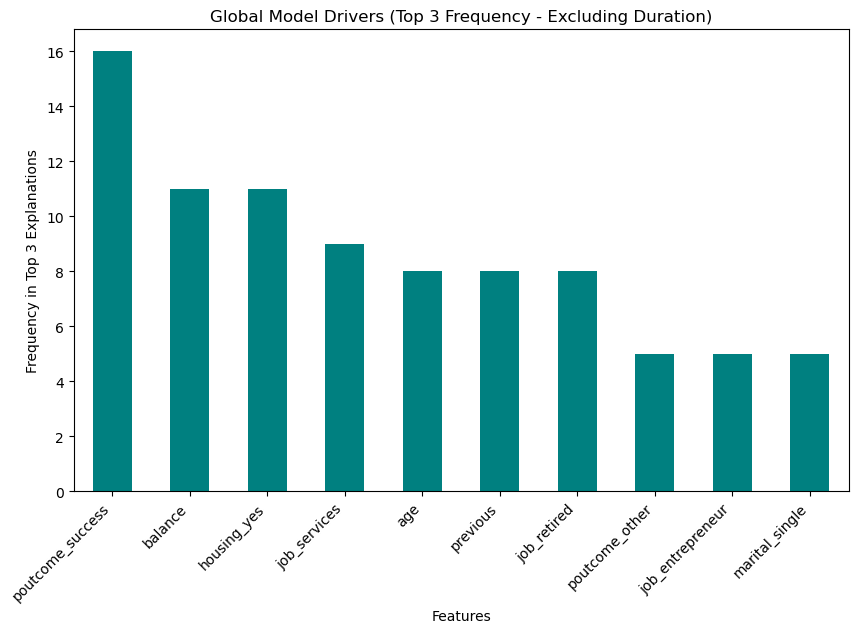

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Aggregating Global Importance (Excluding 'duration' leakage)...")
global_counts_no_leakage = {f:0 for f in feature_names if f != 'duration'}

# Audit top drivers for 50 random samples, skipping 'duration'
for i in range(50):
    weights, fidelity = explainer.explain_instance(X_test_scaled[i], num_samples=1000)
    
    # Create a Series to easily filter out 'duration'
    w_series = pd.Series(weights, index=feature_names)
    if 'duration' in w_series:
        w_series = w_series.drop('duration')
    
    # Find the top 3 features (excluding duration) for this specific decision
    top_3_indices = np.abs(w_series).sort_values(ascending=False).head(3).index
    for feat in top_3_indices:
        global_counts_no_leakage[feat] += 1

# Visualize the "Real" Drivers
global_bias_df = pd.Series(global_counts_no_leakage).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
global_bias_df.plot(kind='bar', color='teal')
plt.title("Global Model Drivers (Top 3 Frequency - Excluding Duration)")
plt.ylabel("Frequency in Top 3 Explanations")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.show()

**The "Good" News: Sound Business Logic**

The fact that `poutcome_success, and balance` are top drivers proves our Neural Network is smart. It has learned fundamental banking principles without being told them:

* poutcome_success (History): The model figured out that "Someone who said YES to us before is likely to say YES again." This is the golden rule of marketing.

* balance (Financials): The model figured out that "People with more money in the bank are better targets for term deposits."

Verdict: The AI is not just guessing; it has learned valid economic indicators.





**Glass Box Validation**

We train a transparent Decision Tree to see if it agrees with LIME.

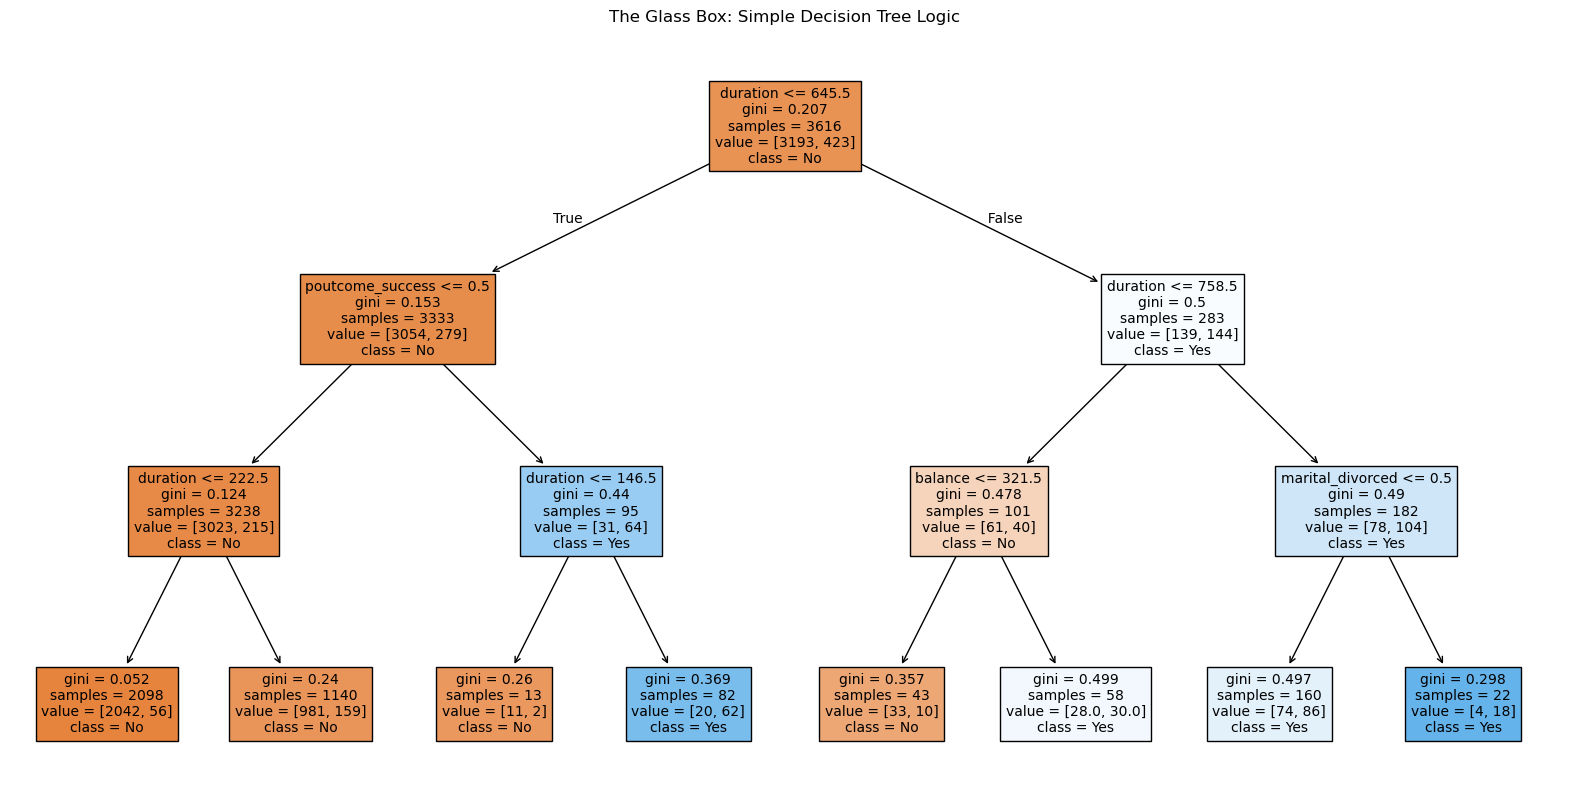

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Train a Glass Box Model (Decision Tree)

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# 2. Visualize the Logic
plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=feature_names, 
          class_names=['No', 'Yes'], 
          filled=True, 
          fontsize=10)
plt.title("The Glass Box: Simple Decision Tree Logic")
plt.show()

**Conclusion**: The Decision Tree confirms that duration is the most critical feature, validating our LIME explanation.

#### Project Conclusion

In this project, we successfully:

* Built a Black Box Neural Network for banking predictions.

* Implemented LIME from scratch to explain individual rejections.

* Audited the model using LIME, discovering that it relies heavily on "Call Duration," which is a form of data leakage.

* Validated our findings using a transparent Decision Tree (Glass Box).

This demonstrates that LIME is a powerful tool not just for explaining decisions to clients, but for detecting flaws in high-accuracy models.